# OpenOrtho AutoDownloader Demo

This notebook demonstrates how to automatically download orthophotos (aerial imagery) for any location in Germany using the **AutoOrthophotoDownloader**.

## Features
- 🎯 **Automatic State Detection**: Automatically detects which German state(s) your area falls into
- 🌈 **Multiple Image Types**: Download RGB, CIR (Color Infrared), or RGBI (4-band merged) imagery
- 📊 **Easy Visualization**: Built-in plotting to visualize downloaded images
- 🗺️ **Flexible Input**: Works with bounding boxes or GeoDataFrames

---

## 1. Import Required Libraries

In [8]:
import sys
from pathlib import Path

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import numpy as np

# Import contextily for basemaps
try:
    import contextily as ctx
    has_contextily = True
except ImportError:
    print("⚠️  contextily not installed. Install with: pip install contextily")
    has_contextily = False

# Import the AutoOrthophotoDownloader
from orthophotos_downloader.data_scraping.auto_downloader import AutoOrthophotoDownloader

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Define Area of Interest

Let's define a bounding box for **Kleinostheim**, a small town in Bavaria, Germany. The coordinates are in **EPSG:25832** (UTM Zone 32N), which is the standard coordinate system for Germany.

You can change these coordinates to any location in Germany!

In [17]:
# Fetch the real boundary of Kleinostheim from OpenStreetMap
import requests
from shapely.geometry import shape

print("🌐 Fetching real boundary of Kleinostheim from OpenStreetMap...")

# Use Nominatim API to get the boundary
nominatim_url = "https://nominatim.openstreetmap.org/search"
params = {
    'q': 'Kleinostheim, Bayern, Germany',
    'format': 'json',
    'polygon_geojson': 1,
    'limit': 1
}

headers = {
    'User-Agent': 'OpenOrtho-Downloader/1.0'
}

try:
    response = requests.get(nominatim_url, params=params, headers=headers)
    response.raise_for_status()
    data = response.json()
    
    if data and len(data) > 0:
        geojson = data[0]['geojson']
        
        # Create shapely geometry from GeoJSON
        kleinostheim_geom = shape(geojson)
        
        # Convert to GeoDataFrame with correct CRS
        from shapely.ops import transform
        import pyproj
        
        # Transform from WGS84 (EPSG:4326) to UTM Zone 32N (EPSG:25832)
        project = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:25832', always_xy=True)
        kleinostheim_geom_utm = transform(project.transform, kleinostheim_geom)
        
        area_gdf = gpd.GeoDataFrame([1], geometry=[kleinostheim_geom_utm], crs="EPSG:25832")
        
        # Get bounds for display
        bounds = kleinostheim_geom_utm.bounds
        west, south, east, north = bounds
        
        print(f"✅ Successfully retrieved boundary of Kleinostheim")
        print(f"   Type: {data[0]['type']}")
        print(f"   Display name: {data[0]['display_name']}")
        print(f"   Area: ~{kleinostheim_geom_utm.area / 1_000_000:.2f} km²")
        
    else:
        print("⚠️  Could not find Kleinostheim boundary, using manual coordinates")
        # Fallback to manual coordinates
        west = 513000
        south = 5538000
        east = 514500
        north = 5539500
        bbox = box(west, south, east, north)
        area_gdf = gpd.GeoDataFrame([1], geometry=[bbox], crs="EPSG:25832")
        
except Exception as e:
    print(f"⚠️  Error fetching boundary: {e}")
    print("   Using manual coordinates instead")
    # Fallback to manual coordinates
    west = 513000
    south = 5538000
    east = 514500
    north = 5539500
    bbox = box(west, south, east, north)
    area_gdf = gpd.GeoDataFrame([1], geometry=[bbox], crs="EPSG:25832")

# Add padding to show surroundings
padding = 500  # 500m padding around the area
padded_bounds = area_gdf.total_bounds
bbox_padded = box(
    padded_bounds[0] - padding, 
    padded_bounds[1] - padding, 
    padded_bounds[2] + padding, 
    padded_bounds[3] + padding
)
area_gdf_padded = gpd.GeoDataFrame([1], geometry=[bbox_padded], crs="EPSG:25832")

🌐 Fetching real boundary of Kleinostheim from OpenStreetMap...
✅ Successfully retrieved boundary of Kleinostheim
   Type: administrative
   Display name: Kleinostheim, Landkreis Aschaffenburg, Bayern, 63801, Deutschland
   Area: ~13.82 km²
✅ Successfully retrieved boundary of Kleinostheim
   Type: administrative
   Display name: Kleinostheim, Landkreis Aschaffenburg, Bayern, 63801, Deutschland
   Area: ~13.82 km²


📍 Area of Interest:
   Location: Kleinostheim, Bavaria
   Size: 5.22 km × 5.65 km
   Padding: 500m around area
   Coordinates: (502129, 5537149) to (507346, 5542802)
   CRS: EPSG:25832
[2025-10-22 15:00:33 - WARNING - matplotlib.legend] No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/ipykernel_92756/1235020318.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=10)


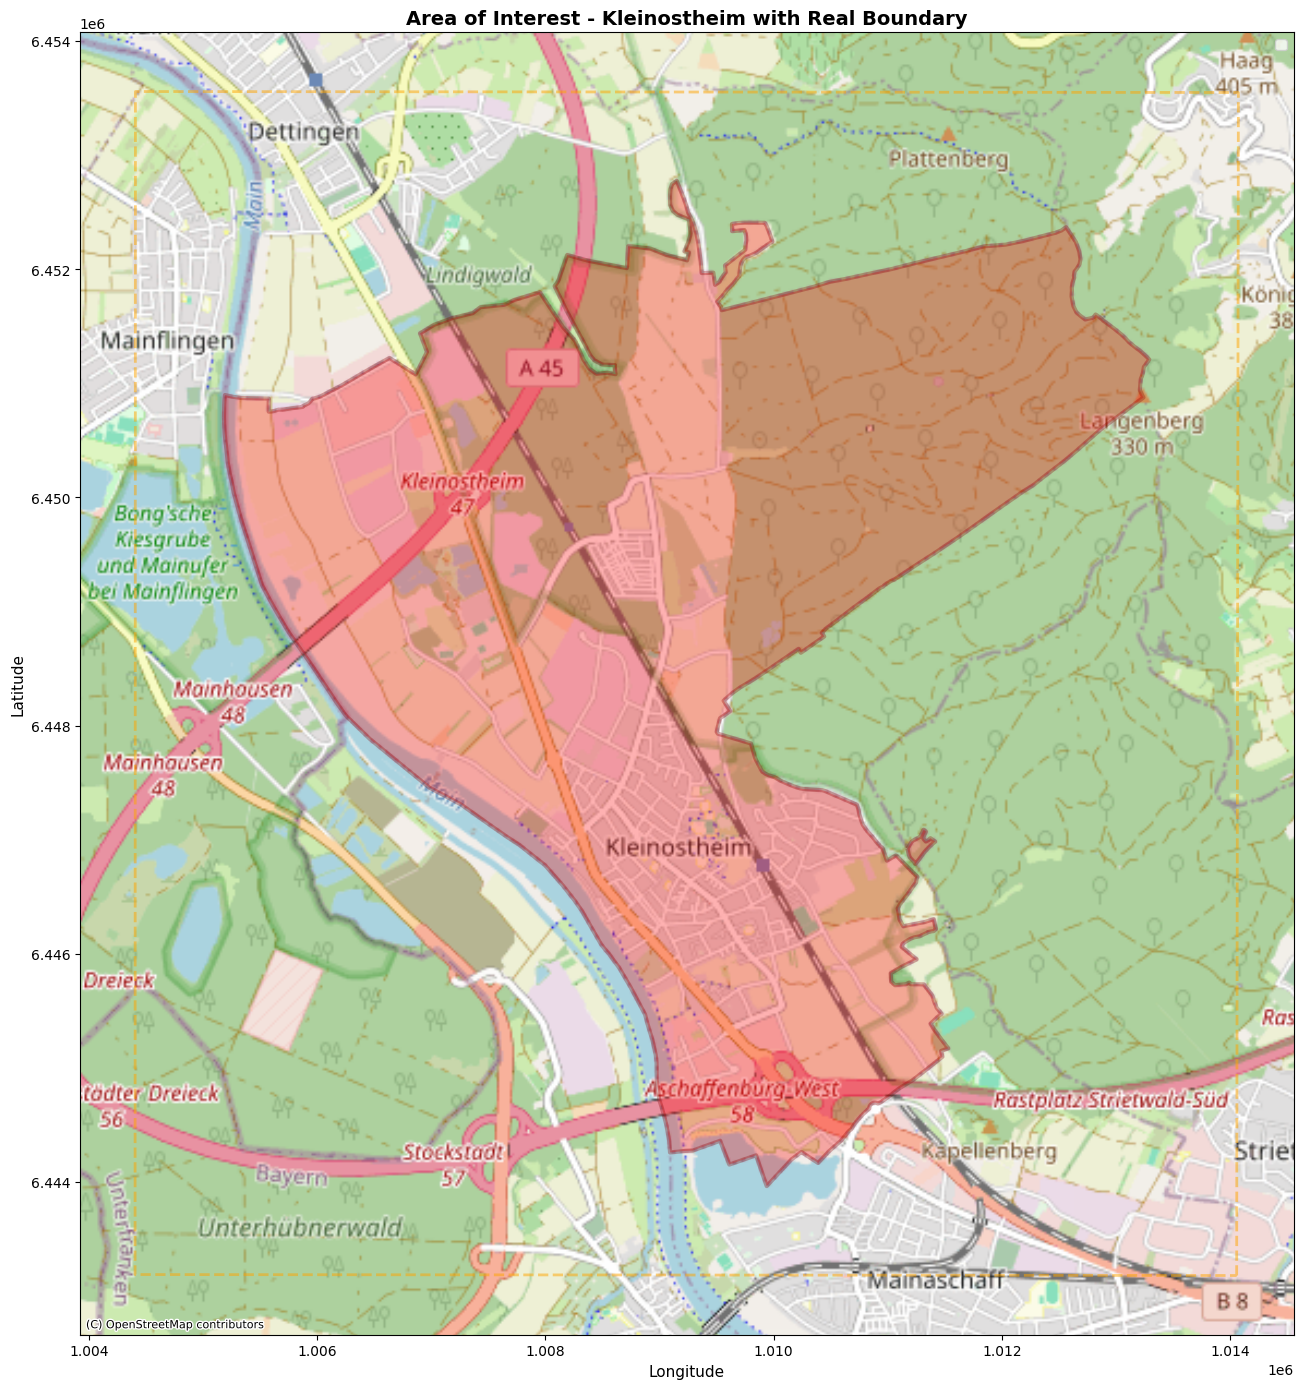

In [19]:
# Display the area information
bounds = area_gdf.total_bounds
west, south, east, north = bounds

print(f"📍 Area of Interest:")
print(f"   Location: Kleinostheim, Bavaria")
print(f"   Size: {(east-west)/1000:.2f} km × {(north-south)/1000:.2f} km")
print(f"   Padding: {padding}m around area")
print(f"   Coordinates: ({west:.0f}, {south:.0f}) to ({east:.0f}, {north:.0f})")
print(f"   CRS: {area_gdf.crs}")

# Visualize the area with background map
fig, ax = plt.subplots(figsize=(14, 14))

if has_contextily:
    # Convert to Web Mercator for basemap
    area_web = area_gdf.to_crs(epsg=3857)
    area_padded_web = area_gdf_padded.to_crs(epsg=3857)
    
    # Plot padded area (for context) and actual boundary
    area_padded_web.plot(ax=ax, facecolor='none', edgecolor='orange', alpha=0.5, linewidth=2, linestyle='--', label='Padded area')
    area_web.plot(ax=ax, facecolor='red', edgecolor='darkred', alpha=0.3, linewidth=3, label='Kleinostheim boundary')
    
    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom='auto')
    
    ax.set_title('Area of Interest - Kleinostheim with Real Boundary', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
else:
    # Fallback without basemap
    area_gdf_padded.plot(ax=ax, facecolor='none', edgecolor='orange', linewidth=2, linestyle='--', label='Padded area')
    area_gdf.plot(ax=ax, facecolor='lightblue', edgecolor='blue', linewidth=2, label='Kleinostheim boundary')
    ax.set_title('Area of Interest - Kleinostheim', fontsize=14, fontweight='bold')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Initialize AutoDownloader & Detect State

The **AutoOrthophotoDownloader** automatically detects which German state(s) your area falls into and uses the appropriate WMS service.

In [14]:
# GRID SIZE CONFIGURATION
# Change grid_spacing to adjust tile size:
# - Smaller values (e.g., 500) = more tiles, higher resolution, longer download
# - Larger values (e.g., 2000) = fewer tiles, lower resolution, faster download
# Common values: 500, 1000 (default), 1500, 2000
grid_spacing = 1000  # meters

# Initialize the AutoDownloader
downloader = AutoOrthophotoDownloader(grid_spacing=grid_spacing)

# Detect which state(s) the area intersects
intersecting_states = downloader.detect_intersecting_states(area_gdf)

print("🎯 Automatic State Detection:")
# intersecting_states returns list of tuples: (state_code, state_name, polygon)
for state_code, state_name, _ in intersecting_states:
    print(f"   Detected State: {state_name} ({state_code})")
print(f"\n✅ AutoDownloader will use the correct WMS service for this state!")
print(f"📏 Grid spacing: {grid_spacing}m")

[2025-10-22 14:56:46 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Loading German federal states from https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json
[2025-10-22 14:56:46 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 2 intersecting states: ['Bayern', 'Hessen']
🎯 Automatic State Detection:
   Detected State: BY (Bayern)
   Detected State: HE (Hessen)

✅ AutoDownloader will use the correct WMS service for this state!
📏 Grid spacing: 1000m
[2025-10-22 14:56:46 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 2 intersecting states: ['Bayern', 'Hessen']
🎯 Automatic State Detection:
   Detected State: BY (Bayern)
   Detected State: HE (Hessen)

✅ AutoDownloader will use the correct WMS service for this state!
📏 Grid spacing: 1000m


## 4b. Download RGB Imagery

RGB imagery shows natural colors (Red, Green, Blue) - what you would see with your eyes.

In [21]:
import time

# Create output directory
output_dir = Path("./data/kleinostheim_demo")
output_dir.mkdir(parents=True, exist_ok=True)

print("📥 Downloading RGB imagery...")
print("   This may take a moment...\n")

# Track download statistics
start_time = time.time()
rgb_datasets = None

try:
    # Download RGB images using the padded area to ensure coverage
    rgb_datasets = downloader.download_rgb_images_auto(
        area_polygon=area_gdf_padded,
        area_name="kleinostheim",
        out_path=output_dir / "rgb",
        filename_prefix="RGB"
    )
    
    download_time = time.time() - start_time
    
    # List downloaded files (they're in state subdirectories)
    rgb_files = list((output_dir / "rgb").rglob("*.tiff"))
    
    # Calculate statistics
    total_size = sum(f.stat().st_size for f in rgb_files) / (1024 * 1024)  # MB
    
    print(f"\n📊 Download Statistics:")
    print(f"   ✅ Downloaded: {len(rgb_files)} image(s)")
    print(f"   ⏱️  Time: {download_time:.2f} seconds")
    print(f"   💾 Total size: {total_size:.2f} MB")
    print(f"   ⚡ Speed: {total_size/download_time:.2f} MB/s")
    print(f"   📁 Saved to: {output_dir / 'rgb'}")
    
    print(f"\n📂 Downloaded Files:")
    for f in rgb_files[:10]:  # Show first 10
        print(f"   - {f.name}")
    if len(rgb_files) > 10:
        print(f"   ... and {len(rgb_files) - 10} more")
        
except Exception as e:
    print(f"❌ Error downloading RGB: {e}")
    rgb_files = []

📥 Downloading RGB imagery...
   This may take a moment...

[2025-10-22 15:01:53 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 2 intersecting states: ['Bayern', 'Hessen']
[2025-10-22 15:01:53 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing Bayern (BY)...
[2025-10-22 15:01:53 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing Bayern (BY)...
[2025-10-22 15:01:53 - INFO - orthophotos_downloader.data_scraping.image_download] Downloading 39 images for kleinostheim_Bayern...
[2025-10-22 15:01:53 - INFO - orthophotos_downloader.data_scraping.image_download] Start downloading image 1 of 39...
[2025-10-22 15:01:53 - INFO - orthophotos_downloader.data_scraping.image_download] Downloading 39 images for kleinostheim_Bayern...
[2025-10-22 15:01:53 - INFO - orthophotos_downloader.data_scraping.image_download] Start downloading image 1 of 39...
[2025-10-22 15:02:13 - INFO - orthophotos_downloader.data_scraping.image_download] Fini

## 5. Download CIR Imagery (Optional)

CIR (Color Infrared) imagery shows vegetation health. Healthy vegetation appears red because it reflects infrared light.

**Note:** Not all German states provide CIR imagery.

In [ ]:
print("📥 Downloading CIR imagery...")

start_time = time.time()

try:
    # Download CIR images
    cir_datasets = downloader.download_cir_images_auto(
        area_polygon=area_gdf_padded,
        area_name="kleinostheim",
        out_path=output_dir / "cir",
        filename_prefix="CIR"
    )
    
    download_time = time.time() - start_time
    
    # List downloaded files (they're in state subdirectories)
    cir_files = list((output_dir / "cir").rglob("*.tiff"))
    
    # Calculate statistics
    total_size = sum(f.stat().st_size for f in cir_files) / (1024 * 1024)  # MB
    
    print(f"\n📊 Download Statistics:")
    print(f"   ✅ Downloaded: {len(cir_files)} image(s)")
    print(f"   ⏱️  Time: {download_time:.2f} seconds")
    print(f"   💾 Total size: {total_size:.2f} MB")
    print(f"   ⚡ Speed: {total_size/download_time:.2f} MB/s")
    print(f"   📁 Saved to: {output_dir / 'cir'}")
    
    print(f"\n📂 Downloaded Files:")
    for f in cir_files[:10]:
        print(f"   - {f.name}")
    if len(cir_files) > 10:
        print(f"   ... and {len(cir_files) - 10} more")
        
except Exception as e:
    print(f"⚠️  CIR not available for this state: {e}")
    cir_files = []

📥 Downloading CIR imagery...
[2025-10-22 14:05:22 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 1 intersecting states: ['Bayern']
[2025-10-22 14:05:22 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing Bayern (BY)...
[2025-10-22 14:05:22 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing Bayern (BY)...
[2025-10-22 14:05:23 - INFO - orthophotos_downloader.data_scraping.image_download] Downloading 1 images for munich_Bayern...
[2025-10-22 14:05:23 - INFO - orthophotos_downloader.data_scraping.image_download] Start downloading image 1 of 1...
[2025-10-22 14:05:23 - INFO - orthophotos_downloader.data_scraping.image_download] Downloading 1 images for munich_Bayern...
[2025-10-22 14:05:23 - INFO - orthophotos_downloader.data_scraping.image_download] Start downloading image 1 of 1...
[2025-10-22 14:05:35 - INFO - orthophotos_downloader.data_scraping.image_download] Finished downloading image 1 in 12.53 seconds.

[2025-10-22 

## 6. Download RGBI Imagery (4-Band Merged)

RGBI combines RGB and CIR into a single 4-band image (Red, Green, Blue, Infrared). This is useful for advanced analysis.

**Note:** Only available where both RGB and CIR exist.

In [ ]:
print("📥 Downloading RGBI imagery...")

start_time = time.time()

try:
    # Download RGBI images (merged RGB + CIR)
    rgbi_datasets = downloader.download_rgbi_images_auto(
        area_polygon=area_gdf_padded,
        area_name="kleinostheim",
        out_path=output_dir / "rgbi"
    )
    
    download_time = time.time() - start_time
    
    # List downloaded files (they're in state subdirectories)
    rgbi_files = list((output_dir / "rgbi").rglob("RGBI_*.tiff"))
    
    # Calculate statistics
    total_size = sum(f.stat().st_size for f in rgbi_files) / (1024 * 1024)  # MB
    
    print(f"\n📊 Download Statistics:")
    print(f"   ✅ Downloaded: {len(rgbi_files)} image(s)")
    print(f"   ⏱️  Time: {download_time:.2f} seconds")
    print(f"   💾 Total size: {total_size:.2f} MB")
    print(f"   ⚡ Speed: {total_size/download_time:.2f} MB/s")
    print(f"   📁 Saved to: {output_dir / 'rgbi'}")
    
    print(f"\n📂 Downloaded Files:")
    for f in rgbi_files[:10]:
        print(f"   - {f.name}")
    if len(rgbi_files) > 10:
        print(f"   ... and {len(rgbi_files) - 10} more")
        
except Exception as e:
    print(f"⚠️  RGBI not available for this state: {e}")
    rgbi_files = []

📥 Downloading RGBI imagery...
[2025-10-22 14:06:12 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 1 intersecting states: ['Bayern']
[2025-10-22 14:06:12 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing RGBI for Bayern (BY)...
[2025-10-22 14:06:12 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing RGBI for Bayern (BY)...
[2025-10-22 14:06:37 - INFO - orthophotos_downloader.data_scraping.image_download] Deleted 2 images from 'data/munich_demo/rgbi/Bayern/temp'.
[2025-10-22 14:06:37 - INFO - orthophotos_downloader.data_scraping.auto_downloader] ✅ Bayern: 1 RGBI images downloaded
✅ Downloaded 1 RGBI image(s)
   Saved to: data/munich_demo/rgbi

📂 Files:
[2025-10-22 14:06:37 - INFO - orthophotos_downloader.data_scraping.image_download] Deleted 2 images from 'data/munich_demo/rgbi/Bayern/temp'.
[2025-10-22 14:06:37 - INFO - orthophotos_downloader.data_scraping.auto_downloader] ✅ Bayern: 1 RGBI images downloaded
✅ Downloaded